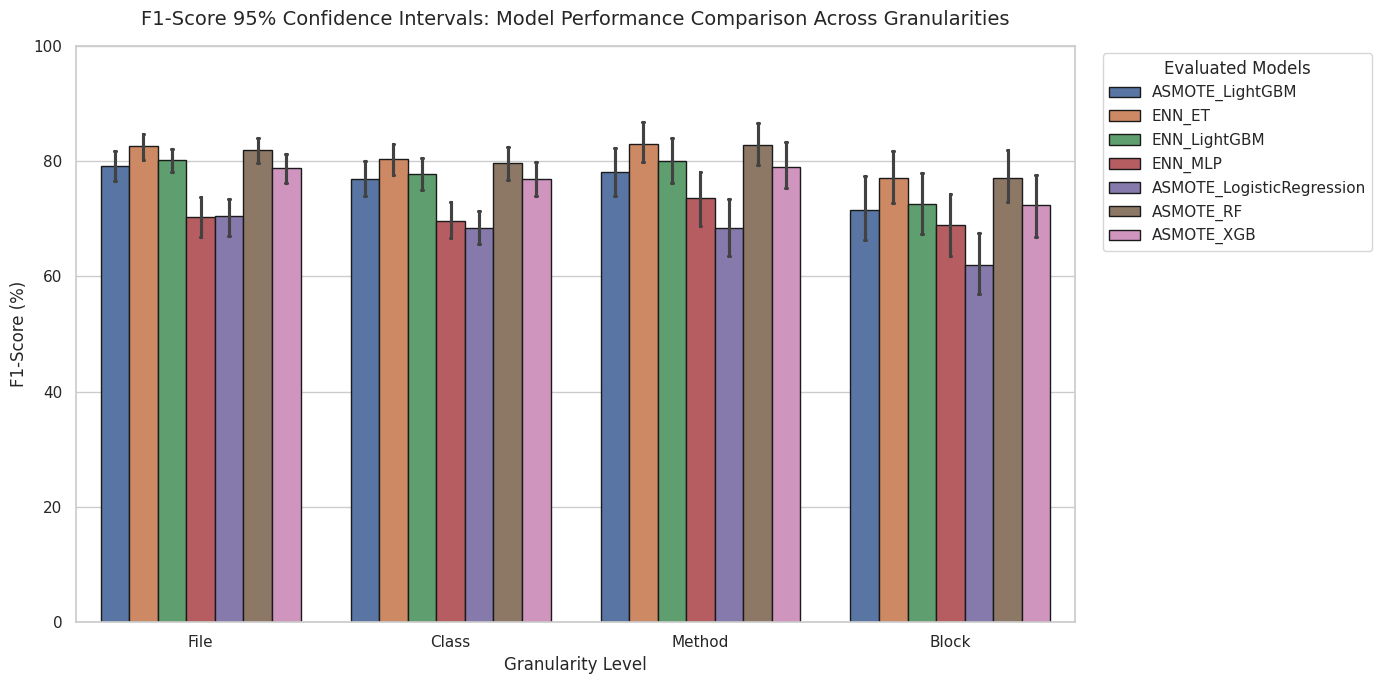

In [6]:
import glob
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Shift = 1
FILE_PREFIX = "within_project_"
FOLDER_PATH = "results/trying_other_models/"

# =====================================================================
# STEP 1: READ THE DATA
# =====================================================================


def clean_cell(text):
    """Removes LaTeX specific formatting elements."""
    text = re.sub(r"\\textbf\{([^}]+)\}", r"\1", text)
    text = re.sub(r"\\[a-zA-Z]+", "", text)
    return text.replace("\\", "").replace("%", "").strip()


def parse_file_metrics(filepath):
    """Parses a file, normalizes decimal/percentage formats, and drops averages."""
    rows = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or "&" not in line:
                continue

            parts = [clean_cell(p) for p in line.split("&")]
            if len(parts) < 21:
                continue

            if parts[0].lower() == "average":
                continue

            try:
                
                # Corrected indices for F1-score: 3, 8, 13, 18
                raw_file = float(parts[3 +  Shift])
                raw_class = float(parts[8 + Shift])
                raw_method = float(parts[13 + Shift])
                raw_block = float(parts[18 + Shift])

                # Normalize everything to a 0-100% scale
                # If a value is <= 1.0 (and not explicitly 0), it's treated as a decimal
                file_f1 = raw_file * 100 if 0 < raw_file <= 1.0 else raw_file
                class_f1 = raw_class * 100 if 0 < raw_class <= 1.0 else raw_class
                method_f1 = (
                    raw_method * 100 if 0 < raw_method <= 1.0 else raw_method
                )
                block_f1 = (
                    raw_block * 100 if 0 < raw_block <= 1.0 else raw_block
                )

                rows.append(
                    {
                        "Project": parts[0],
                        "File": file_f1,
                        "Class": class_f1,
                        "Method": method_f1,
                        "Block": block_f1,
                    }
                )
            except ValueError:
                continue
    return pd.DataFrame(rows)



def load_all_models(prefix="within_project_"):
    """Discovers files and pairs model names with their extracted dataframes."""
    datasets = {}
    search_path = os.path.join(FOLDER_PATH, f"{prefix}*")
    for filepath in glob.glob(search_path):
        filename = os.path.basename(filepath)
        model_name = filename.replace(prefix, "").replace(".txt", "")

        df = parse_file_metrics(filepath)
        if not df.empty:
            datasets[model_name] = df
    return datasets

# =====================================================================
# STEP 2: RESTRUCTURE FOR COMPREHENSIVE VISUALIZATION
# =====================================================================


def build_comparison_dataset(datasets):
    """Converts independent wide dataframes into a master unified dataset."""
    compiled_frames = []

    for model_name, df in datasets.items():
        melted_df = df.melt(
            id_vars=["Project"],
            value_vars=["File", "Class", "Method", "Block"],
            var_name="Granularity",
            value_name="F1_Score",
        )
        melted_df["Model"] = model_name
        compiled_frames.append(melted_df)

    return (
        pd.concat(compiled_frames, ignore_index=True)
        if compiled_frames
        else pd.DataFrame()
    )


# =====================================================================
# STEP 3: PLOT THE COMPREHENSIVE COMPARISON
# =====================================================================


def plot_model_comparison(comparison_df):
    """Plots confidence intervals of all models across granularities."""
    if comparison_df.empty:
        print("No processed data found to generate plots.")
        return

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # This structure places Granularity on the X-axis and groups bars by individual Models
    sns.barplot(
        data=comparison_df,
        x="Granularity",
        y="F1_Score",
        hue="Model",
        errorbar="ci",  # Computes 95% Confidence Interval across the distinct projects
        capsize=0.05,
        edgecolor="0.1",
    )

    plt.title(
        "F1-Score 95% Confidence Intervals: Model Performance Comparison Across Granularities",
        fontsize=14,
        pad=15,
    )
    plt.ylabel("F1-Score (%)", fontsize=12)
    plt.xlabel("Granularity Level", fontsize=12)
    plt.ylim(0, 100)

    # Position the legend comfortably off to the side to handle a large list of models
    plt.legend(
        title="Evaluated Models", bbox_to_anchor=(1.02, 1), loc="upper left"
    )

    plt.tight_layout()
    plt.show()


# =====================================================================
# MAIN RUNNER
# =====================================================================
if __name__ == "__main__":
    # Module 1: Extract
    raw_data = load_all_models()

    # Module 2: Transform
    master_df = build_comparison_dataset(raw_data)

    # Module 3: Visualize
    plot_model_comparison(master_df)

/tmp/ipykernel_69666/1910293108.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_69666/1910293108.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


AttributeError: 'FacetGrid' object has no attribute 'get_title'

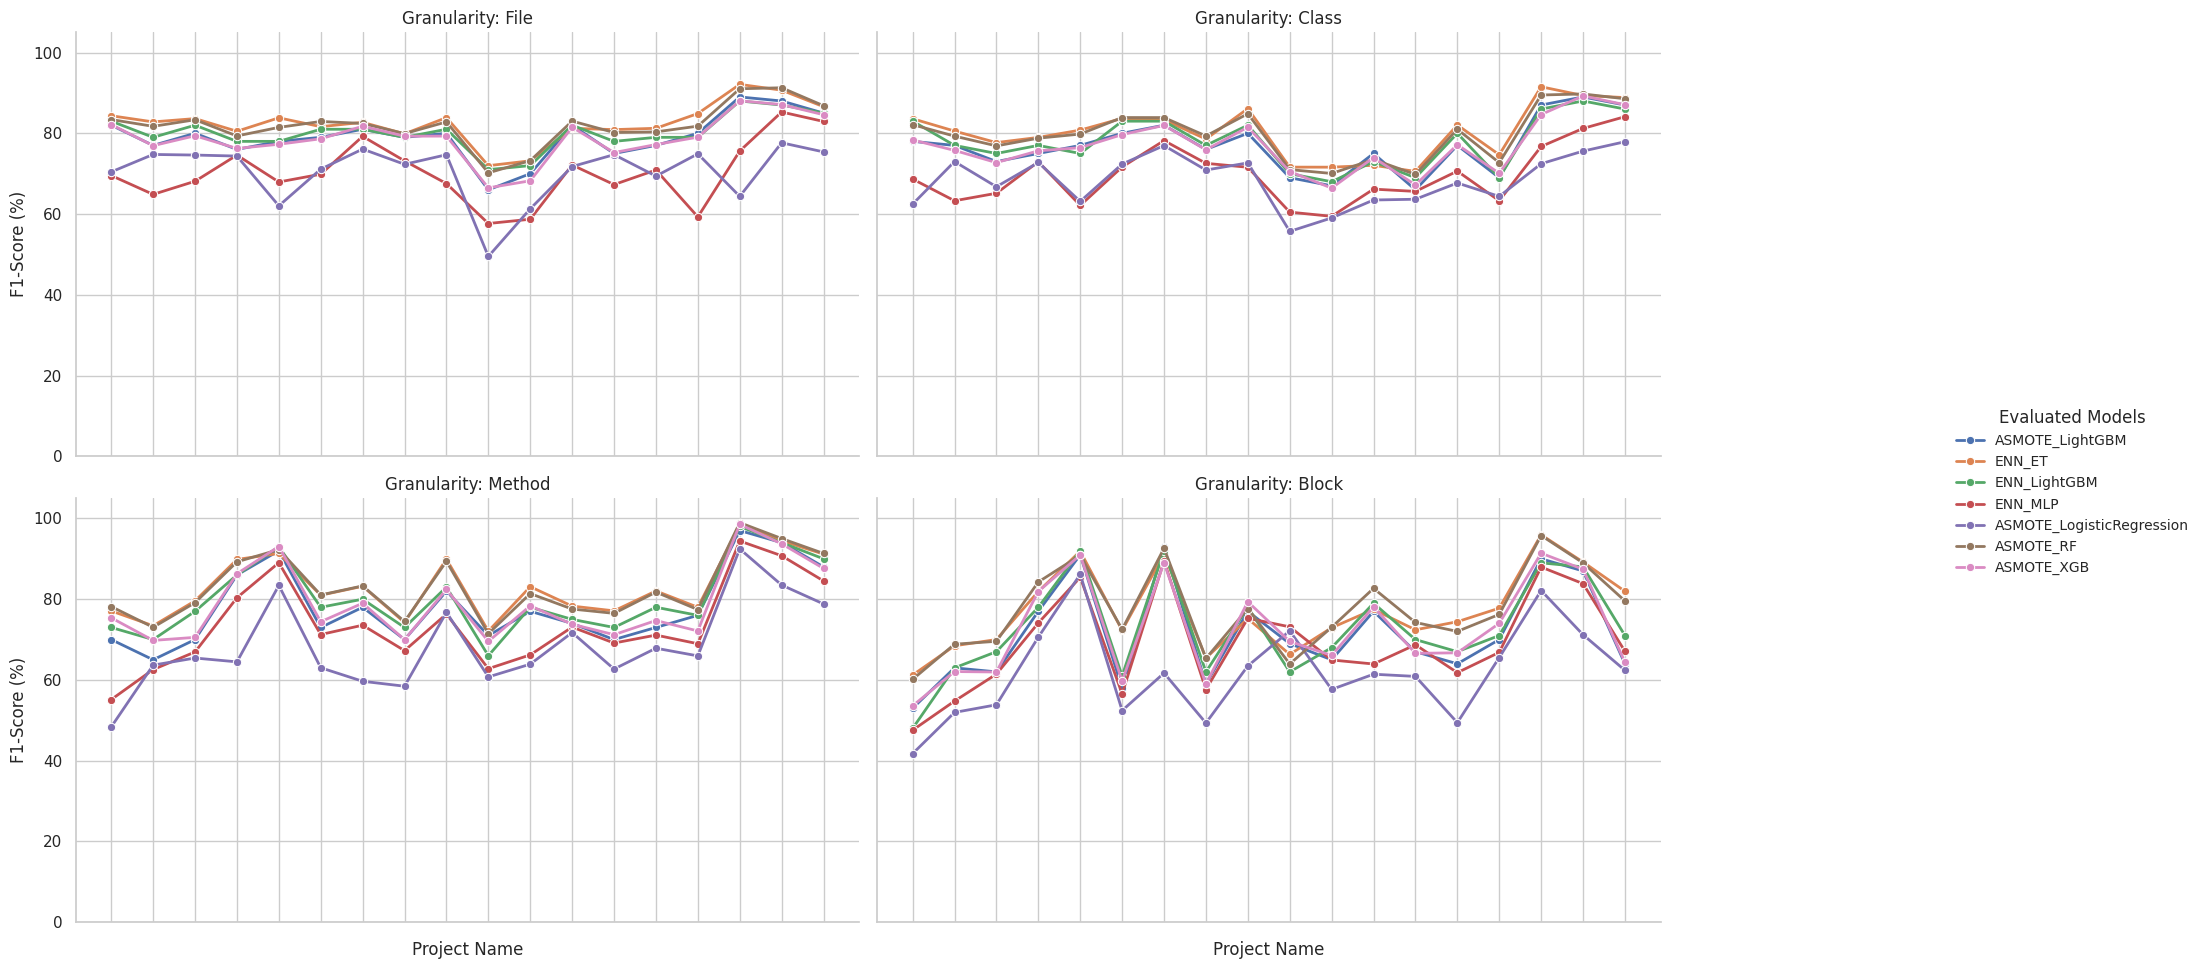

In [7]:
# =====================================================================
# STEP 3: PLOTTING FUNCTION (FIXED OVERLAPS)
# =====================================================================


def plot_granularity_line_charts(comparison_df):
    """Plots a 2x2 grid of line charts, one for each granularity level,

    with all overlaps resolved.
    """
    if comparison_df.empty:
        print("No processed data found to generate plots.")
        return

    sns.set_theme(style="whitegrid")
    granularity_order = ["File", "Class", "Method", "Block"]

    g = sns.FacetGrid(
        data=comparison_df,
        col="Granularity",
        col_wrap=2,
        height=5,
        aspect=1.7,
        col_order=granularity_order,
        sharey=True,
    )

    g.map_dataframe(
        sns.lineplot,
        x="Project",
        y="F1_Score",
        hue="Model",
        marker="o",
        linewidth=2.0,
    )

    g.set_axis_labels("", "")

    for ax_idx, ax in enumerate(g.axes.flat):
        if ax_idx >= 2:
            ax.set_xlabel("Project Name", fontsize=12)
        granularity = granularity_order[ax_idx]
        ax.set_title(f"Granularity: {granularity}", fontsize=12)

    g.axes.flat[0].set_ylabel("F1-Score (%)", fontsize=12)
    g.axes.flat[2].set_ylabel("F1-Score (%)", fontsize=12)
    g.set(ylim=(0, 105))

    for ax in g.axes.flat:
        ax.set_xticklabels(
            ax.get_xticklabels(), rotation=90, ha="center", fontsize=10
        )

    legend_title = "Evaluated Models"
    legend = g.add_legend(
        title=legend_title,
        bbox_to_anchor=(1.01, 0.5),
        loc="center left",
        fontsize=10,
        title_fontsize=11,
    )

    if legend:
        legend.get_title().set_text(legend_title)
        for t in legend.get_texts():
            t.set_text(t.get_text().strip())

    plt.subplots_adjust(bottom=0.25, right=0.82)
    plt.show()


# =====================================================================
# FIXED MAIN RUNNER
# =====================================================================
if __name__ == "__main__":
    # 1. Read data
    raw_projects = load_all_models(prefix=FILE_PREFIX)

    if not raw_projects:
        print(
            f"No matching data files found in '{FOLDER_PATH}' with prefix '{FILE_PREFIX}'"
        )
    else:
        # 2. Transform data (Corrected function name)
        prepared_df = build_comparison_dataset(raw_projects)

        # 3. Plot data (Corrected dataframe variable)
        plot_granularity_line_charts(prepared_df)